# Task 2: Customer Segmentation Using Unsupervised Learning

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

### Dataset:
Mall Customers Dataset (Kaggle)

### Techniques Used:
- K-Means Clustering
- PCA (Principal Component Analysis) for visualization
- Elbow Method to find optimal clusters

### Tools Used:
Python 3.10, pandas, numpy, matplotlib, seaborn, scikit-learn

In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================================
# Step 2: Load the Mall Customers Dataset
# ============================================================

df = pd.read_csv('Mall_Customers.csv')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
Total Rows: 200
Total Columns: 5


In [4]:
# ============================================================
# Step 3: First Look at the Dataset
# ============================================================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# ============================================================
# Step 4: Dataset Structure and Basic Info
# ============================================================

print("Dataset Shape:", df.shape)
print()

print("Column Names and Data Types:")
print("-" * 45)
for col in df.columns:
    print(f"  {col:30s} -> {df[col].dtype}")
print()

print("Statistical Summary:")
df.describe()

Dataset Shape: (200, 5)

Column Names and Data Types:
---------------------------------------------
  CustomerID                     -> int64
  Gender                         -> object
  Age                            -> int64
  Annual Income (k$)             -> int64
  Spending Score (1-100)         -> int64

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# ============================================================
# Step 5: Check for Missing Values
# ============================================================

print("Missing Values in Each Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\nNo missing values! Dataset is clean.")

# Rename columns for easier use
df.rename(columns={
    'CustomerID': 'customer_id',
    'Genre': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}, inplace=True)

print("\nColumns renamed successfully!")
print("New column names:", df.columns.tolist())

Missing Values in Each Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total Missing Values: 0

No missing values! Dataset is clean.

Columns renamed successfully!
New column names: ['customer_id', 'Gender', 'age', 'annual_income', 'spending_score']


## Exploratory Data Analysis (EDA)

Understanding the distribution and relationships between:
1. Gender Distribution
2. Age Distribution
3. Annual Income Distribution
4. Spending Score Distribution
5. Relationships between features

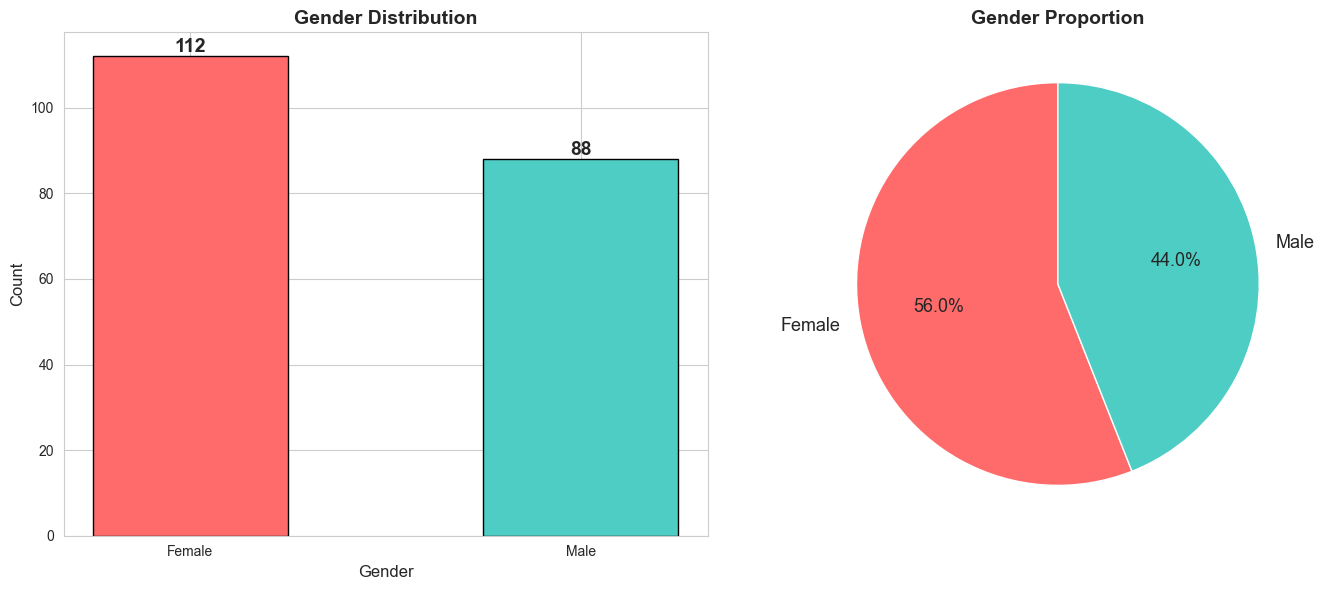

Female customers: 112 (56.0%)
Male customers: 88 (44.0%)


In [10]:
# ============================================================
# Step 6: Gender Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
gender_counts = df['Gender'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(gender_counts.index, gender_counts.values, 
            color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=14, fontweight='bold')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Gender Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Female customers: {gender_counts['Female']} ({gender_counts['Female']/len(df)*100:.1f}%)")
print(f"Male customers: {gender_counts['Male']} ({gender_counts['Male']/len(df)*100:.1f}%)")

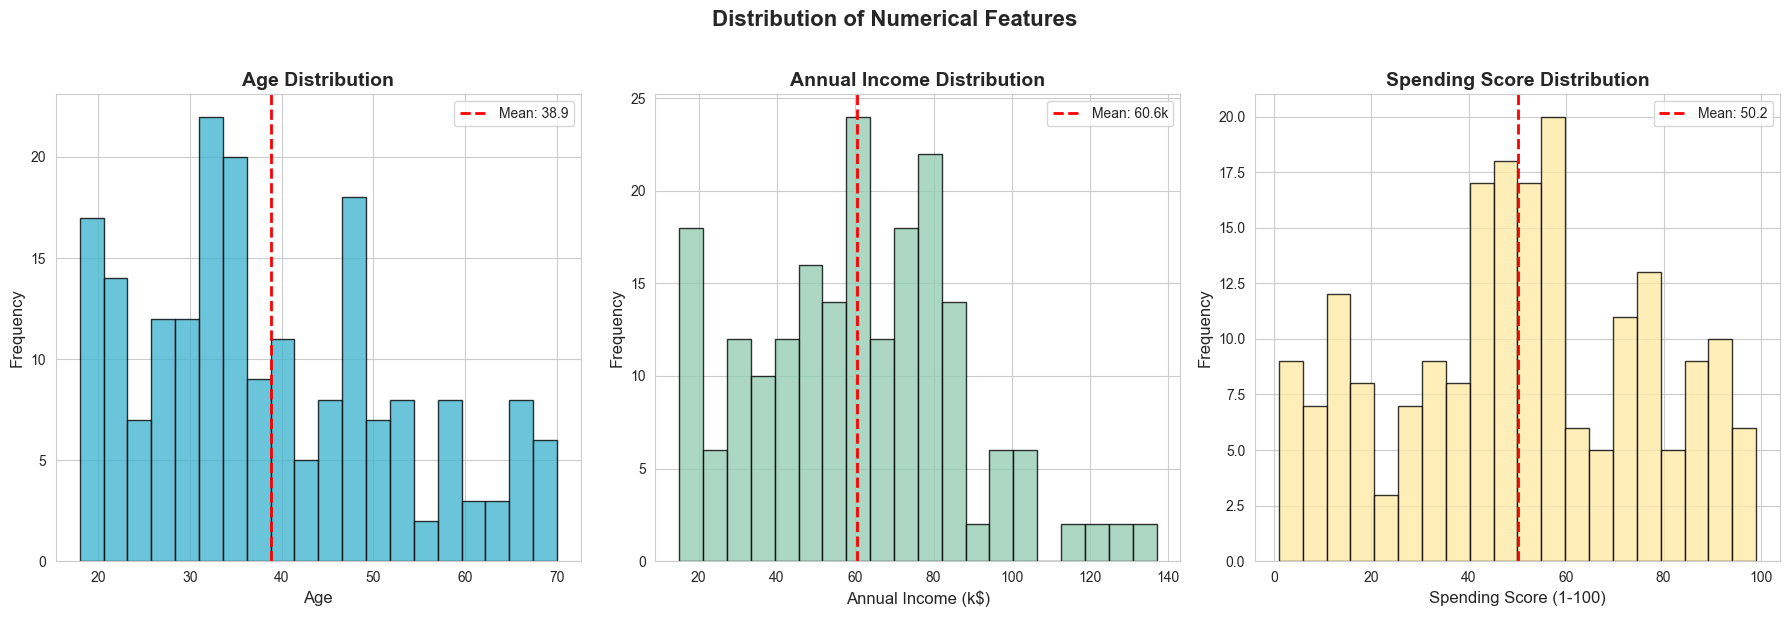

In [9]:
# ============================================================
# Step 7: Distribution of Numerical Features
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age Distribution
axes[0].hist(df['age'], bins=20, color='#45B7D1', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {df['age'].mean():.1f}")
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Annual Income Distribution
axes[1].hist(df['annual_income'], bins=20, color='#96CEB4', edgecolor='black', alpha=0.8)
axes[1].axvline(df['annual_income'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['annual_income'].mean():.1f}k")
axes[1].set_title('Annual Income Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

# Spending Score Distribution
axes[2].hist(df['spending_score'], bins=20, color='#FFEAA7', edgecolor='black', alpha=0.8)
axes[2].axvline(df['spending_score'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['spending_score'].mean():.1f}")
axes[2].set_title('Spending Score Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Spending Score (1-100)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend()

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

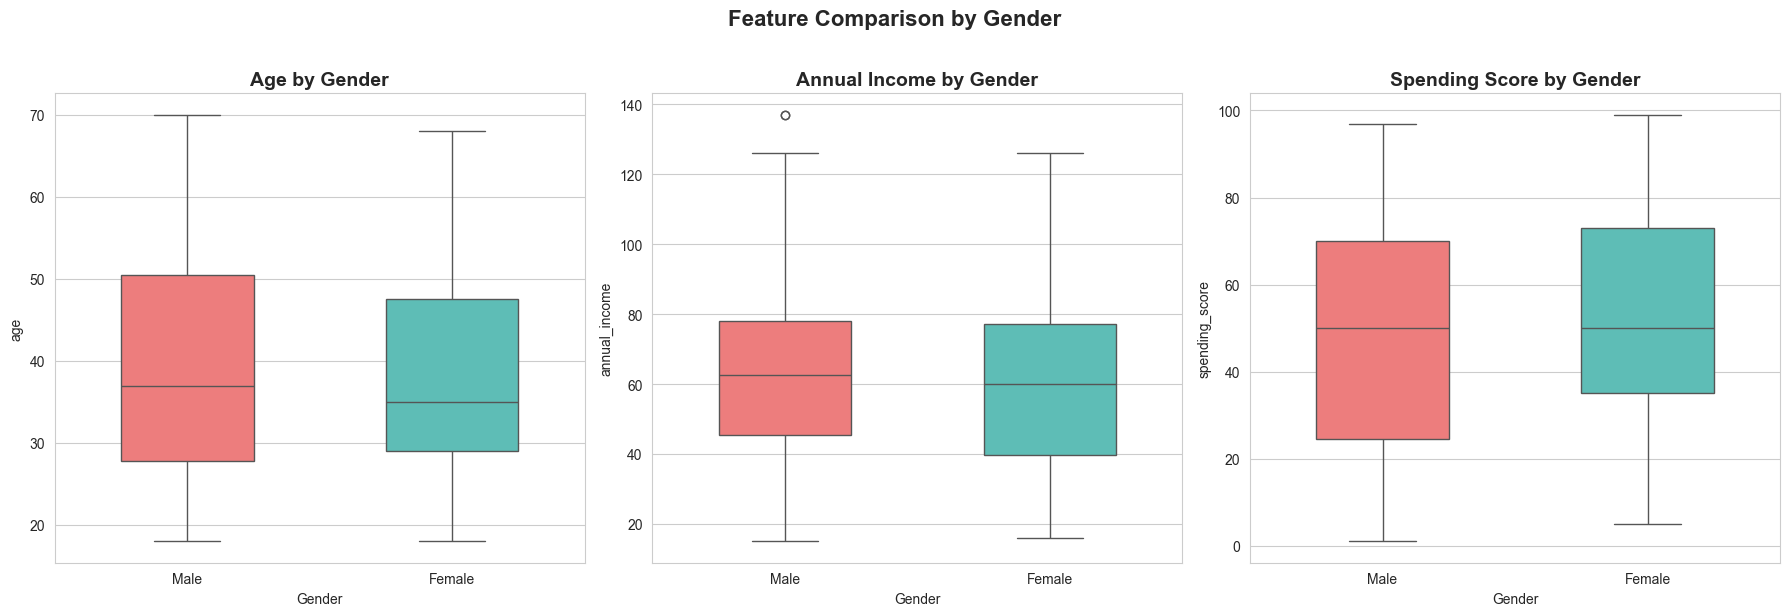

In [12]:
# ============================================================
# Step 8: Box Plots - Compare Features by Gender
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age by Gender
sns.boxplot(data=df, x='Gender', y='age', ax=axes[0],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[0].set_title('Age by Gender', fontsize=14, fontweight='bold')

# Income by Gender
sns.boxplot(data=df, x='Gender', y='annual_income', ax=axes[1],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[1].set_title('Annual Income by Gender', fontsize=14, fontweight='bold')

# Spending Score by Gender
sns.boxplot(data=df, x='Gender', y='spending_score', ax=axes[2],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[2].set_title('Spending Score by Gender', fontsize=14, fontweight='bold')

plt.suptitle('Feature Comparison by Gender', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

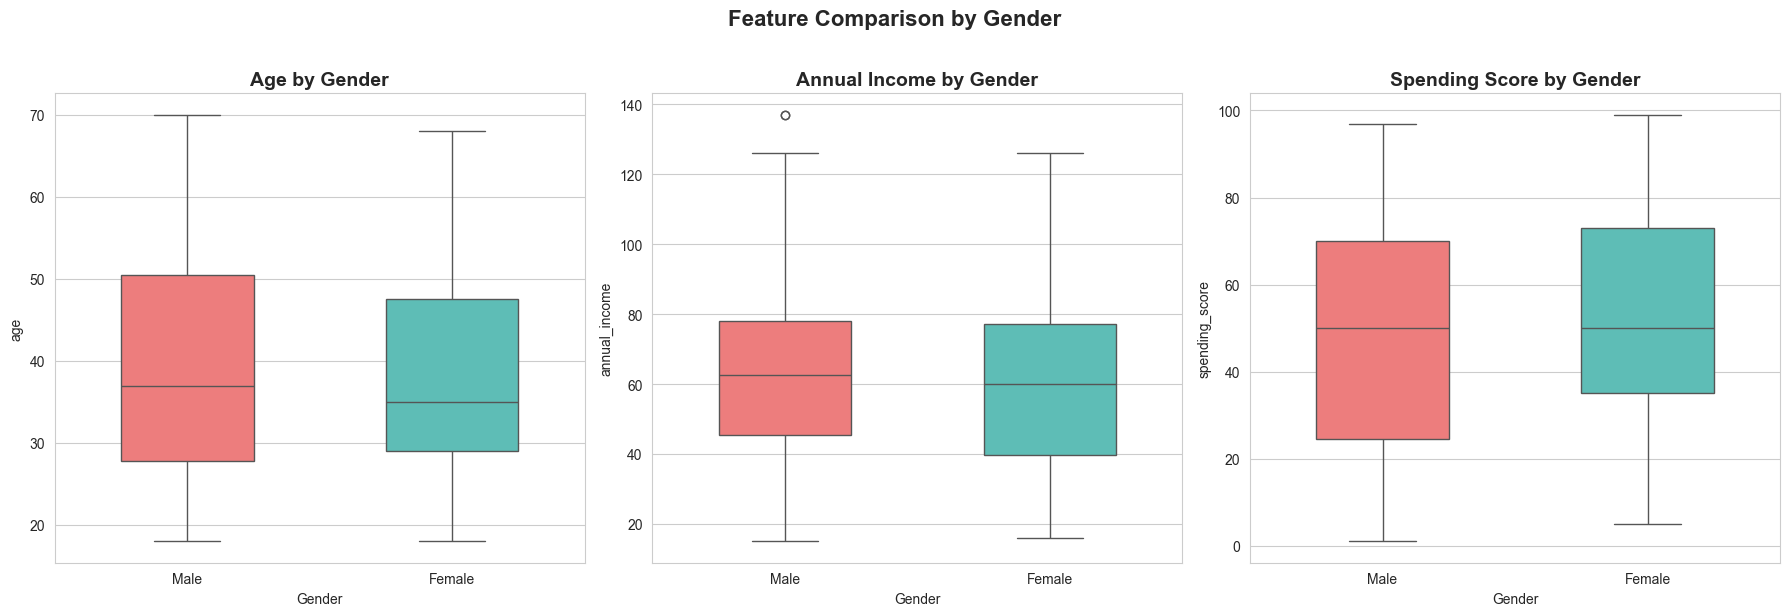

In [13]:
# ============================================================
# Step 8: Box Plots - Compare Features by Gender
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age by Gender
sns.boxplot(data=df, x='Gender', y='age', ax=axes[0],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[0].set_title('Age by Gender', fontsize=14, fontweight='bold')

# Income by Gender
sns.boxplot(data=df, x='Gender', y='annual_income', ax=axes[1],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[1].set_title('Annual Income by Gender', fontsize=14, fontweight='bold')

# Spending Score by Gender
sns.boxplot(data=df, x='Gender', y='spending_score', ax=axes[2],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[2].set_title('Spending Score by Gender', fontsize=14, fontweight='bold')

plt.suptitle('Feature Comparison by Gender', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

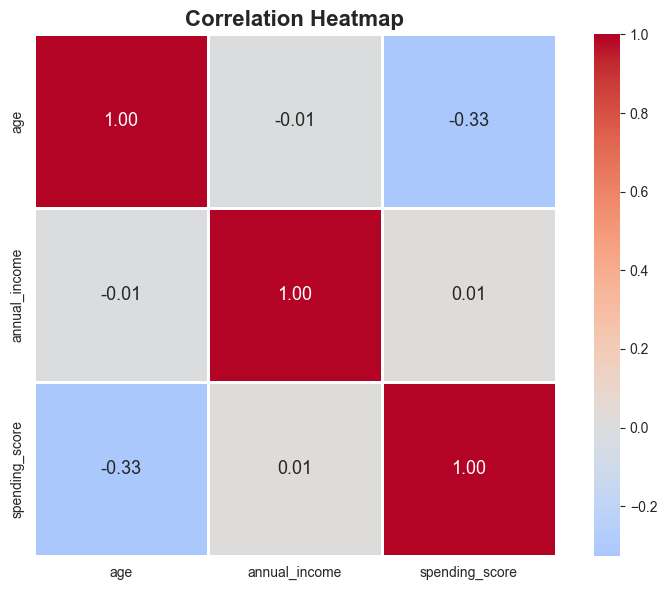

In [14]:
# ============================================================
# Step 10: Correlation Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include='number').drop('customer_id', axis=1)
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, fmt='.2f',
            annot_kws={'fontsize': 13})

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## K-Means Clustering

### Steps:
1. Select features for clustering (Annual Income + Spending Score)
2. Scale the features using StandardScaler
3. Use Elbow Method to find optimal number of clusters
4. Apply K-Means with optimal K
5. Visualize clusters
6. Use PCA for 3D visualization

In [15]:
# ============================================================
# Step 11: Select Features and Scale Them
# ============================================================

# Select features for clustering
# Using Annual Income and Spending Score as main features
X = df[['annual_income', 'spending_score']].copy()

# Scale features so they have equal importance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
print("  1. Annual Income")
print("  2. Spending Score")
print()
print(f"Data scaled successfully!")
print(f"Scaled data shape: {X_scaled.shape}")

Features selected for clustering:
  1. Annual Income
  2. Spending Score

Data scaled successfully!
Scaled data shape: (200, 2)


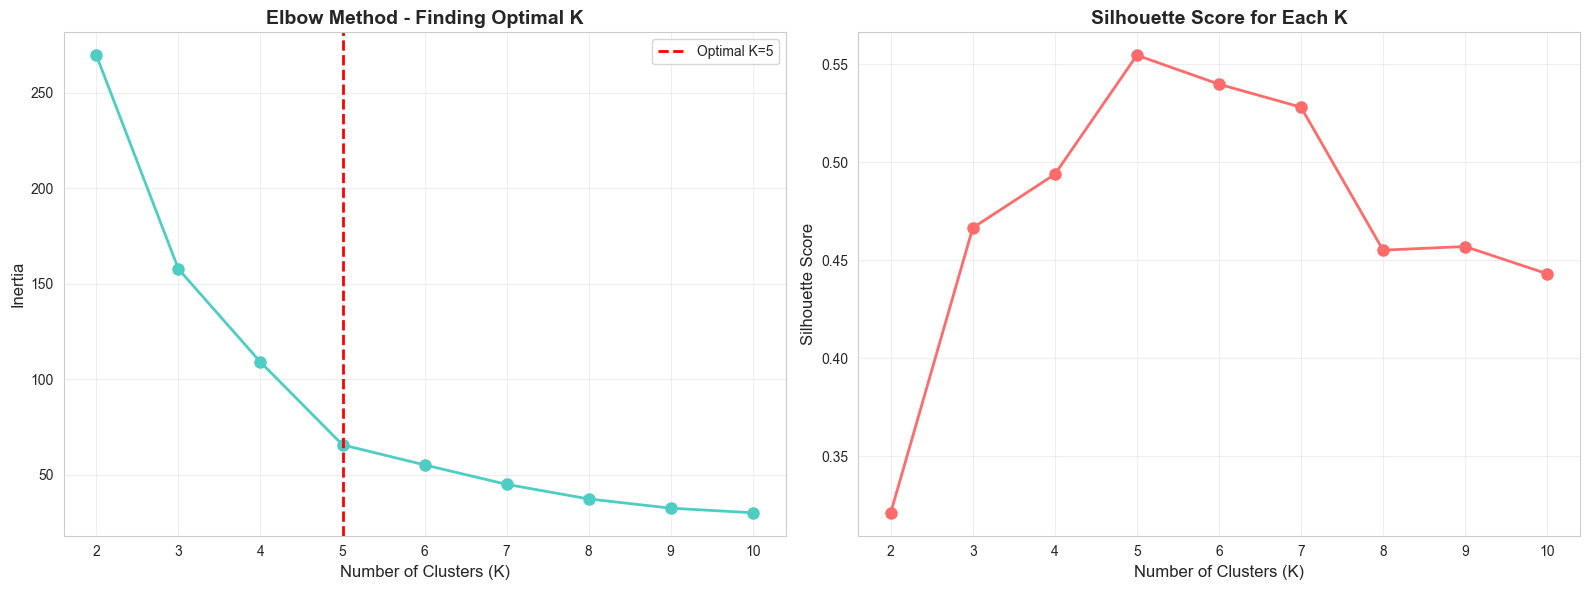

Optimal number of clusters: K = 5
(Based on Elbow Method - where curve bends)


In [16]:
# ============================================================
# Step 12: Elbow Method - Find Optimal Number of Clusters
# ============================================================
# The elbow method runs K-Means for different values of K
# and plots the inertia (sum of squared distances)
# The "elbow" point is the optimal K

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8, color='#4ECDC4')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[0].set_title('Elbow Method - Finding Optimal K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8, color='#FF6B6B')
axes[1].set_title('Silhouette Score for Each K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal number of clusters: K = 5")
print(f"(Based on Elbow Method - where curve bends)")

In [17]:
# ============================================================
# Step 13: Apply K-Means Clustering with K=5
# ============================================================

# Apply K-Means with optimal K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering applied with K={optimal_k}")
print()
print("Number of customers in each cluster:")
print("-" * 40)
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} customers")

print()
print("Cluster Centers (in original scale):")
centers = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(centers):
    print(f"  Cluster {i}: Income=${center[0]:.1f}k, Spending Score={center[1]:.1f}")

K-Means clustering applied with K=5

Number of customers in each cluster:
----------------------------------------
  Cluster 0: 81 customers
  Cluster 1: 39 customers
  Cluster 2: 22 customers
  Cluster 3: 35 customers
  Cluster 4: 23 customers

Cluster Centers (in original scale):
  Cluster 0: Income=$55.3k, Spending Score=49.5
  Cluster 1: Income=$86.5k, Spending Score=82.1
  Cluster 2: Income=$25.7k, Spending Score=79.4
  Cluster 3: Income=$88.2k, Spending Score=17.1
  Cluster 4: Income=$26.3k, Spending Score=20.9


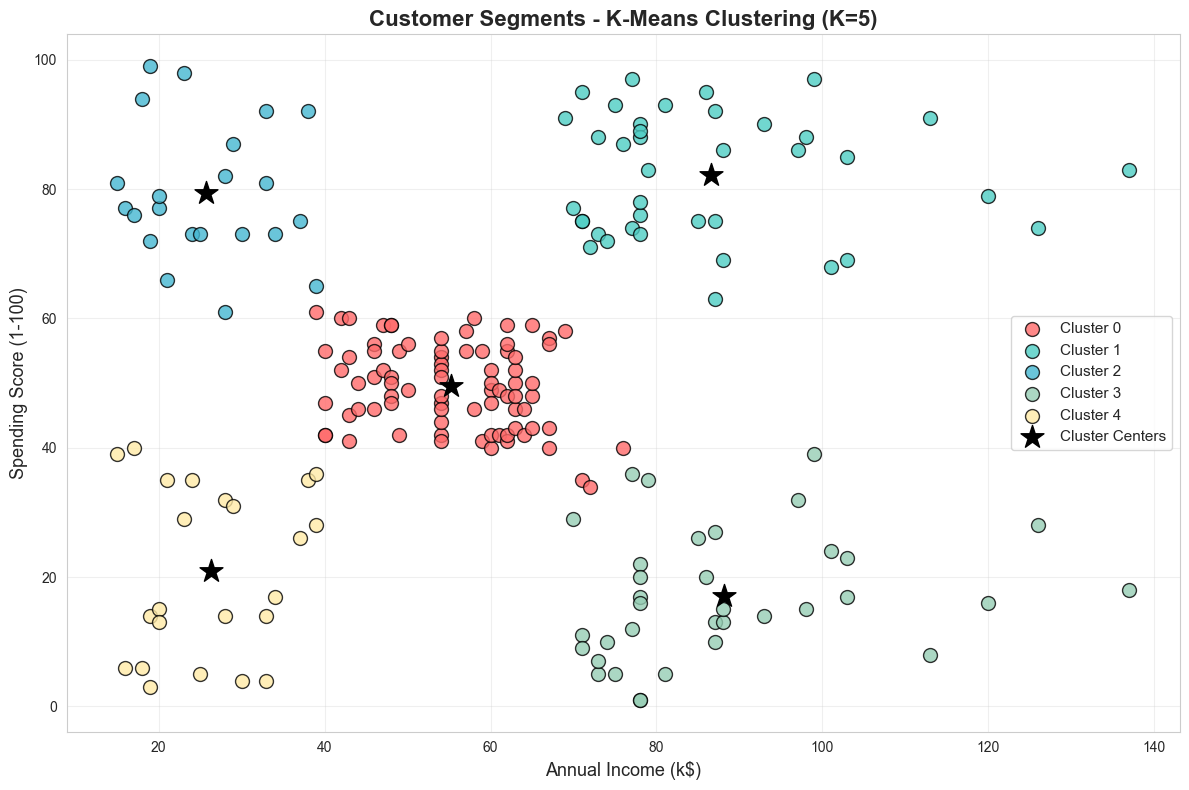

In [18]:
# ============================================================
# Step 14: Visualize Customer Segments
# ============================================================

# Define cluster names based on characteristics
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

plt.figure(figsize=(12, 8))

for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    plt.scatter(cluster_data['annual_income'], cluster_data['spending_score'],
                c=colors[cluster], label=f'Cluster {cluster}',
                s=100, edgecolor='black', alpha=0.8)

# Plot cluster centers
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c='black', marker='*', s=300, zorder=5, label='Cluster Centers')

plt.title('Customer Segments - K-Means Clustering (K=5)', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Step 15: Analyze Each Cluster in Detail
# ============================================================

print("=" * 60)
print("DETAILED CLUSTER ANALYSIS")
print("=" * 60)

cluster_labels = {
    0: 'Medium Income, Medium Spending',
    1: 'High Income, Low Spending (Careful Spenders)',
    2: 'Low Income, High Spending (Impulsive Buyers)',
    3: 'High Income, High Spending (Target Customers)',
    4: 'Low Income, Low Spending (Budget Conscious)'
}

for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\nCluster {cluster} Profile:")
    print(f"  Number of Customers: {len(cluster_data)}")
    print(f"  Average Age: {cluster_data['age'].mean():.1f}")
    print(f"  Average Annual Income: ${cluster_data['annual_income'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['spending_score'].mean():.1f}")
    print(f"  Gender Split: {cluster_data['Gender'].value_counts().to_dict()}")
    print("-" * 40)

DETAILED CLUSTER ANALYSIS

Cluster 0 Profile:
  Number of Customers: 81
  Average Age: 42.7
  Average Annual Income: $55.3k
  Average Spending Score: 49.5
  Gender Split: {'Female': 48, 'Male': 33}
----------------------------------------

Cluster 1 Profile:
  Number of Customers: 39
  Average Age: 32.7
  Average Annual Income: $86.5k
  Average Spending Score: 82.1
  Gender Split: {'Female': 21, 'Male': 18}
----------------------------------------

Cluster 2 Profile:
  Number of Customers: 22
  Average Age: 25.3
  Average Annual Income: $25.7k
  Average Spending Score: 79.4
  Gender Split: {'Female': 13, 'Male': 9}
----------------------------------------

Cluster 3 Profile:
  Number of Customers: 35
  Average Age: 41.1
  Average Annual Income: $88.2k
  Average Spending Score: 17.1
  Gender Split: {'Male': 19, 'Female': 16}
----------------------------------------

Cluster 4 Profile:
  Number of Customers: 23
  Average Age: 45.2
  Average Annual Income: $26.3k
  Average Spending Score:

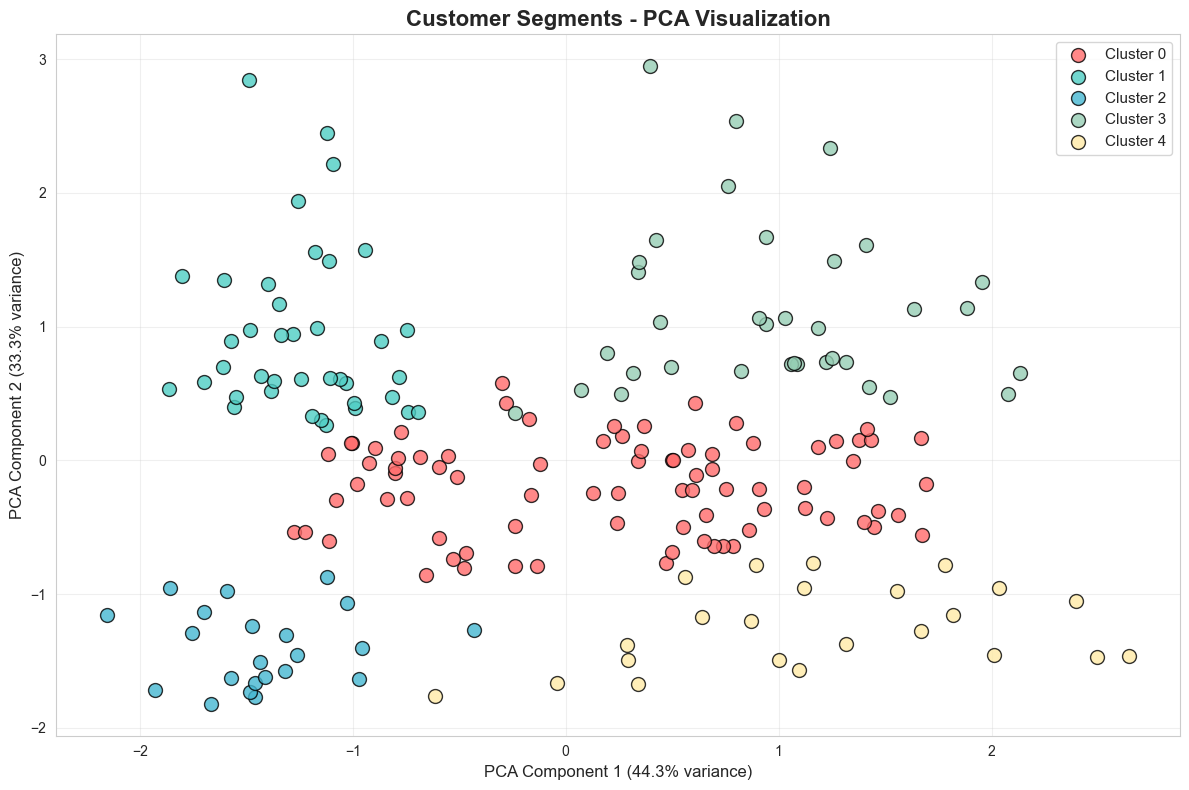

Total variance explained by 2 PCA components: 77.6%


In [21]:
# ============================================================
# Step 16: PCA - Dimensionality Reduction for Visualization
# ============================================================
# PCA reduces dimensions to 2D so we can visualize clusters better
# Here we use all 3 features (age, income, spending_score)

# Prepare all features for PCA
X_all = df[['age', 'annual_income', 'spending_score']].copy()
X_all_scaled = StandardScaler().fit_transform(X_all)

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PCA Component 1', 'PCA Component 2'])
pca_df['cluster'] = df['cluster']

# Plot PCA visualization
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for cluster in range(optimal_k):
    cluster_data = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(cluster_data['PCA Component 1'], cluster_data['PCA Component 2'],
                c=colors[cluster], label=f'Cluster {cluster}',
                s=100, edgecolor='black', alpha=0.8)

plt.title('Customer Segments - PCA Visualization', fontsize=16, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCA components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

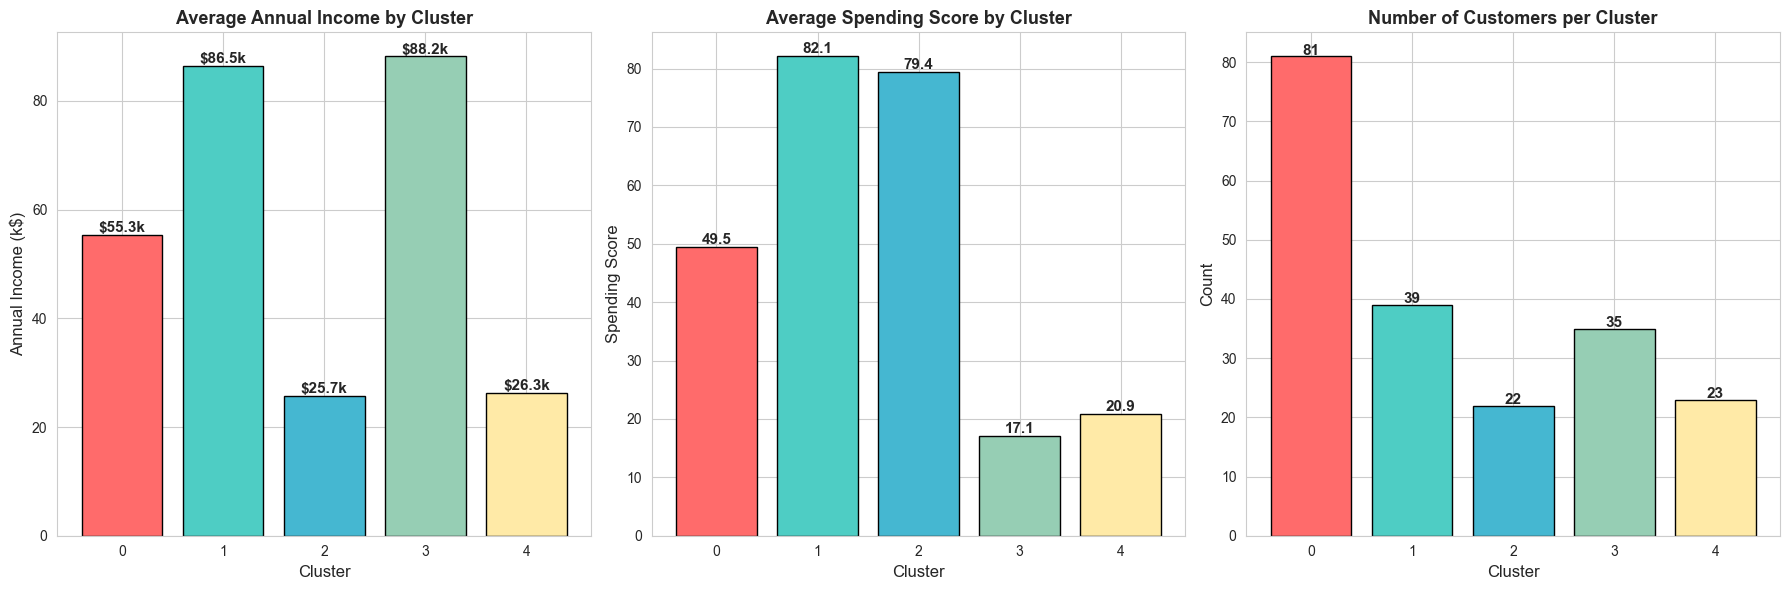

In [22]:
# ============================================================
# Step 17: Compare Clusters with Bar Charts
# ============================================================

cluster_summary = df.groupby('cluster').agg({
    'age': 'mean',
    'annual_income': 'mean',
    'spending_score': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'count'}).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Average Income per Cluster
axes[0].bar(range(optimal_k), cluster_summary['annual_income'],
            color=colors, edgecolor='black')
axes[0].set_title('Average Annual Income by Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Annual Income (k$)', fontsize=12)
for i, v in enumerate(cluster_summary['annual_income']):
    axes[0].text(i, v + 0.5, f'${v}k', ha='center', fontsize=11, fontweight='bold')

# Average Spending Score per Cluster
axes[1].bar(range(optimal_k), cluster_summary['spending_score'],
            color=colors, edgecolor='black')
axes[1].set_title('Average Spending Score by Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Spending Score', fontsize=12)
for i, v in enumerate(cluster_summary['spending_score']):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

# Customer Count per Cluster
axes[2].bar(range(optimal_k), cluster_summary['count'],
            color=colors, edgecolor='black')
axes[2].set_title('Number of Customers per Cluster', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cluster', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
for i, v in enumerate(cluster_summary['count']):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Marketing Strategies for Each Customer Segment

Based on the K-Means clustering analysis, here are tailored marketing strategies:

### Cluster 0 - Medium Income, Medium Spending
- **Strategy**: Loyalty Programs
- Offer reward points and membership cards
- Provide moderate discounts to increase spending
- Send personalized product recommendations

### Cluster 1 - High Income, Low Spending (Careful Spenders)
- **Strategy**: Premium Product Marketing
- Showcase high-quality, exclusive products
- Offer premium membership with added benefits
- Focus on value-for-money messaging

### Cluster 2 - Low Income, High Spending (Impulsive Buyers)
- **Strategy**: Flash Sales and Offers
- Send time-limited discount alerts
- Offer buy-now-pay-later options
- Use emotional marketing campaigns

### Cluster 3 - High Income, High Spending (Target Customers ⭐)
- **Strategy**: VIP Treatment - HIGHEST PRIORITY
- Offer VIP membership and exclusive access
- Personalized luxury product recommendations
- Invite to exclusive events and launches

### Cluster 4 - Low Income, Low Spending (Budget Conscious)
- **Strategy**: Budget-Friendly Promotions
- Offer bundle deals and combo offers
- Provide affordable alternatives
- Focus on essential products marketing

## Conclusion

### Key Findings from Customer Segmentation:

1. **Dataset Overview**: The Mall Customers dataset contains 200 customers with features including gender, age, annual income, and spending score.

2. **Optimal Clusters**: The Elbow Method and Silhouette Score both indicated that K=5 is the optimal number of customer segments.

3. **Customer Segments Identified**:
   - Cluster 0: Medium Income, Medium Spending (Balanced customers)
   - Cluster 1: High Income, Low Spending (Conservative spenders)
   - Cluster 2: Low Income, High Spending (Impulsive buyers)
   - Cluster 3: High Income, High Spending (Premium customers - Best target)
   - Cluster 4: Low Income, Low Spending (Budget-conscious customers)

4. **Key Observations**:
   - Female customers slightly outnumber male customers
   - High Income + High Spending customers (Cluster 3) are the most valuable segment
   - PCA explained significant variance with just 2 components

5. **Business Recommendation**:
   - Prioritize marketing efforts on Cluster 3 (High Income, High Spending)
   - Use loyalty programs for Cluster 0 to increase spending
   - Target Cluster 1 with premium product campaigns

### Overall Insight:
Customer segmentation helps businesses allocate their marketing budget efficiently by targeting the right customers with the right strategies.